In [1]:
from GNN import GATv2SequenceModel
from dataset_processing import DatasetProcessing
import json
import networkx as nx
from torch_geometric.utils import to_networkx
import random
import torch
from torch.utils.data import DataLoader

In [2]:
dataset_process=DatasetProcessing()

with open("data_KrEc.json","r") as f:
    test_set=json.load(f)
a,label_list=dataset_process.modified(test_set)
a=a[11:]
sequence_list,sequence_labels=dataset_process.create_sequence_and_labels(a,label_list,50)

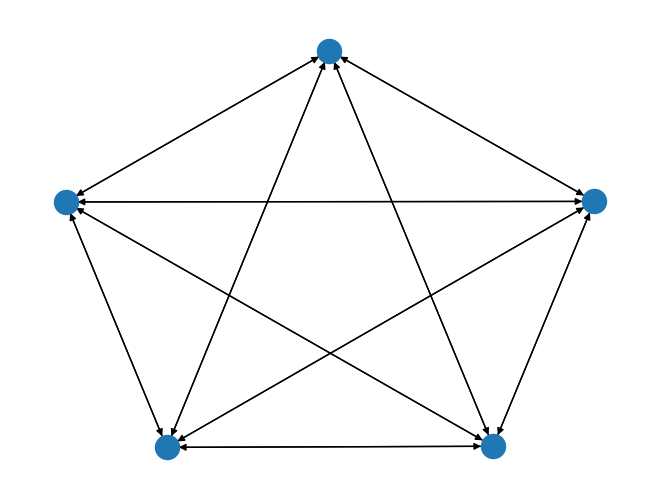

In [3]:
asd=to_networkx(sequence_list[0][5])
nx.draw(asd)

In [4]:
dataset=[]
for graphs,labels in zip(sequence_list,sequence_labels):
    dataset.append((graphs,[labels[0],labels[1][0],labels[1][1]]))

In [5]:
# def collate_fn(batch):
#     """
#     Custom collate function for handling sequences of graphs.
#     Input:
#         batch: List of tuples (sequence of graphs, label)
#     Output:
#         sequences: List of sequences (each sequence is a list of graphs)
#         labels: Tensor of labels
#     """
#     sequences, labels, bool_labels = zip(*batch)
#     return (
#         list(sequences),
#         torch.tensor(labels, dtype=torch.long),
#         torch.tensor(bool_labels, dtype=torch.float),
#     )


# train_loader = DataLoader(
#     dataset=dataset, batch_size=1, shuffle=True, collate_fn=collate_fn
# )

In [6]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [7]:


# ELAVULT




# in_channels = 13
# hidden_channels = 16
# out_channels = 11
# edge_dim = 1
# heads = 1
# num_epochs = 10
# learning_rate = 0.001

# model = GATv2SequenceModel(
#     in_channels=in_channels,
#     hidden_channels=hidden_channels,
#     edge_dim=edge_dim,
#     out_channels=out_channels,
#     heads=heads,
# ).to("cuda")

# criterion = torch.nn.CrossEntropyLoss()
# criterion_bools=torch.nn.BCEWithLogitsLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


# for epoch in range(num_epochs):
#     model.train()
#     total_loss = 0

#     for sequences, labels, bool_labels in train_loader:
#         # Move data to GPU if available
#         sequences = [[graph.to("cuda") for graph in seq] for seq in sequences]
#         print(sequences)
#         labels = labels.to("cuda")
#         bool_labels=bool_labels.to("cuda")
#         print(f"Sequences shape (before model): {len(sequences)}")  # Debugging
#         outputs,bools = model(sequences)

#         print(f"Outputs shape: {outputs.shape}")  # Debugging
#         print(f"Labels shape: {labels.shape}")    # Debugging

#         # Compute loss
#         loss_class = criterion(outputs, labels)
#         loss_bool =criterion_bools(bools,bool_labels)
#         loss=loss_class+loss_bool

#         # Backward pass and optimization
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     avg_loss = total_loss / len(train_loader)
#     print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

In [8]:
# torch.save(model.state_dict(),"trained.pth")

In [9]:

# HOW TO USE MODELLLLLL
# from torch_geometric.data import Batch

# model=GATv2SequenceModel(13,16,1,11)
# batched_graph=Batch.from_data_list(sequence_list[0])
# # Step 2: Extract the graph data
# x = batched_graph.x                  # Node features
# edge_index = batched_graph.edge_index  # Edge indices
# edge_attr = batched_graph.edge_attr    # Edge attributes
# batch = batched_graph.batch            # Batch vector (indicates which graph each node belongs to)

# # Step 3: Sequence length (number of graphs in this sequence)
# sequence_length = [len(sequence_list[0])]  # Only one sequence, so its length is the full sequence

# # Step 4: Pass through the model
# out, out_bool = model(x, edge_index, edge_attr, batch, sequence_length)

In [10]:
from torch_geometric.data import Batch
import torch

def collate_batch(data_list):
    """
    Custom collate function to batch sequences of graphs.
    
    Args:
        data_list: List of tuples [(sequence_of_graphs, sequence_label), ...].
                   Each sequence_of_graphs is a list of PyG Data objects.
                   Each sequence_label is the corresponding label for the sequence.
    
    Returns:
        batched_graphs: Batched PyG graphs.
        sequence_lengths: List of sequence lengths in the batch.
        labels: Tensor of sequence labels.
    """
    all_graphs = []  # Flatten all graphs in the batch
    sequence_lengths = []  # Store the length of each sequence
    labels = []  # Store the labels for each sequence

    for sequence_of_graphs, label in data_list:
        all_graphs.extend(sequence_of_graphs)  # Add all graphs in the sequence
        sequence_lengths.append(len(sequence_of_graphs))  # Length of the sequence
        labels.append(label)
    
    # Batch all graphs using PyG's Batch class
    batched_graphs = Batch.from_data_list(all_graphs)

    # Convert everything to tensors
    sequence_lengths = torch.tensor(sequence_lengths, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)

    return batched_graphs, sequence_lengths, labels

In [12]:
num_epochs=1
device="cuda"
in_channels = 13
hidden_channels = 32
out_channels = 13
edge_dim = 1
heads = 1
num_epochs = 100
learning_rate = 0.0001
batch_size=8

model = GATv2SequenceModel(
    in_channels=in_channels,
    hidden_channels=hidden_channels,
    edge_dim=edge_dim,
    out_channels=out_channels,
    heads=heads,
).to("cuda")

data_loader=DataLoader(dataset,batch_size=batch_size,collate_fn=collate_batch,shuffle=False)
classification_loss_fn = torch.nn.CrossEntropyLoss()  # For multi-class classification
bool_loss_fn = torch.nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)



for epoch in range(num_epochs):
    model.train()
    for batched_graphs, sequence_lengths, labels in data_loader:
        # Move data to device (GPU/CPU)
        batched_graphs = batched_graphs.to(device)
        sequence_lengths = sequence_lengths.to("cpu")
        labels = labels.to(device)

        # Separate labels into components
        class_labels = labels[:, 0]  # First column: class labels (shape [batch_size])
        bool_labels = labels[:, 1:]  # Second and third columns: boolean labels (shape [batch_size, 2])

        # Forward pass
        out = model(
            x=batched_graphs.x,
            edge_index=batched_graphs.edge_index,
            edge_attr=batched_graphs.edge_attr,
            batch=batched_graphs.batch,
            sequence_lengths=sequence_lengths,
        )

        # Compute losses
        class_loss = classification_loss_fn(out, class_labels)  # CrossEntropyLoss
        # bool_loss = bool_loss_fn(out_bool, bool_labels.float())  # BCEWithLogitsLoss

        # Combine losses (optional weighting)
        total_loss = class_loss

        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {total_loss.item()}")

Epoch 1, Loss: 2.5946855545043945
Epoch 2, Loss: 2.5609610080718994
Epoch 3, Loss: 2.542062997817993
Epoch 4, Loss: 2.5322914123535156
Epoch 5, Loss: 2.50419020652771
Epoch 6, Loss: 2.4668662548065186
Epoch 7, Loss: 2.4479358196258545
Epoch 8, Loss: 2.4045941829681396
Epoch 9, Loss: 2.3465969562530518
Epoch 10, Loss: 2.2656900882720947
Epoch 11, Loss: 2.236220121383667
Epoch 12, Loss: 2.228673219680786
Epoch 13, Loss: 2.1965267658233643
Epoch 14, Loss: 2.1622250080108643
Epoch 15, Loss: 2.1834118366241455
Epoch 16, Loss: 2.1810572147369385
Epoch 17, Loss: 2.1609456539154053
Epoch 18, Loss: 2.157358169555664
Epoch 19, Loss: 2.175705671310425
Epoch 20, Loss: 2.140238046646118
Epoch 21, Loss: 2.1519477367401123
Epoch 22, Loss: 2.15016770362854
Epoch 23, Loss: 2.135345458984375
Epoch 24, Loss: 2.1616060733795166
Epoch 25, Loss: 2.1602401733398438
Epoch 26, Loss: 2.1700375080108643
Epoch 27, Loss: 2.1666111946105957
Epoch 28, Loss: 2.148665189743042
Epoch 29, Loss: 2.1293628215789795
Epoch 